# Moments of the Wigner Semicircle


---

## Background

When a large Hermitian matrix is filled with random Gaussian entries, drawn from the Gaussian Unitary Ensemble, its eigenvalues do not spread out arbitrarily. As the size grows they pack into a fixed shape, the Wigner semicircle supported on the interval $[-2,2]$, and the details of the individual entries wash out. This convergence to a single limiting spectral density holds across a wide range of entry distributions.

A convenient way to characterize the semicircle is through its moments, the averages of successive powers of the eigenvalue. Because the semicircle is symmetric about zero, every odd moment cancels. The even moments are more interesting, and they turn out to be the Catalan numbers $C_k = \tfrac{1}{k+1}\binom{2k}{k}$, a sequence that appears all over combinatorics.

The appearance of the Catalan numbers is more than a curiosity, because they count non-crossing pairings of points, and the very same non-crossing pairings organize the Weingarten calculus used later to evaluate Haar integrals over unitaries. The spectral shape of random Hermitian matrices and the algebra of random unitaries are speaking the same combinatorial language. Reading off the lowest moments gives $m_2 = 1$ and $m_4 = 2$, and their ratio $m_4/m_2^2 = 2$ reports a tail lighter than a Gaussian would have, a consequence of the hard edge where the semicircle stops.

The notebook evaluates the low moments by a trigonometric substitution and matches them to the Catalan sequence.

## Mathematical background

For a Wigner matrix with entries scaled so the spectrum stays of order one, the empirical eigenvalue density converges to the semicircle law

$$
\rho(x) = \frac{1}{2\pi}\sqrt{4 - x^2}, \qquad x \in [-2, 2].
$$

Its moments are cleanest combinatorially. The odd moments vanish by symmetry, and the even moments are the Catalan numbers,

$$
m_{2k} = \int_{-2}^{2} x^{2k}\,\rho(x)\,dx = C_k = \frac{1}{k+1}\binom{2k}{k}.
$$

The origin is a moment expansion of $\mathbb{E}\!\left[\tfrac1N \mathrm{Tr}\,H^{2k}\right]$ into closed walks on the matrix indices. At large $N$ only the walks that pair their steps without crossing survive, and the number of non-crossing pairings of $2k$ objects is exactly $C_k$. The first values $m_2 = 1$, $m_4 = 2$, $m_6 = 5$ are $C_1, C_2, C_3$. This is the spectral analogue of the Gaussian Wick theorem with non-crossing pairings in place of all pairings, and it is the entry point to free probability, where the semicircle plays the role the Gaussian plays for independent variables.

## Exercise

The Wigner semicircle density on $[-2, 2]$ is

$$
\rho_{\mathrm{sc}}(\lambda) = \frac{1}{2\pi}\sqrt{4 - \lambda^2}.
$$

Define the moments $m_k = \int_{-2}^{2} \lambda^k\, \rho_{\mathrm{sc}}(\lambda)\, d\lambda$.

**(a)** Show all odd moments vanish: $m_{2k+1} = 0$.

**(b)** Compute $m_2$ and verify $m_2 = 1$.

**(c)** Compute $m_4$ and show $m_4 = 2$. Identify the pattern: $m_{2k} = C_k$ (Catalan numbers).

**(d)** Interpret $m_4/m_2^2 = 2 < 3$ (platykurtic).

## Solution

### Part (a): Odd moments vanish

The density $\rho_{\mathrm{sc}}(\lambda)$ is an **even function**: $\rho_{\mathrm{sc}}(-\lambda) = \rho_{\mathrm{sc}}(\lambda)$. For odd $k$, the integrand $\lambda^k \rho_{\mathrm{sc}}(\lambda)$ is odd on the symmetric interval $[-2, 2]$:

$$
m_{2k+1} = \int_{-2}^{2} \lambda^{2k+1}\, \rho_{\mathrm{sc}}(\lambda)\, d\lambda = 0. \quad \checkmark
$$

### Part (b): Second moment

Use the substitution $\lambda = 2\sin\theta$, $d\lambda = 2\cos\theta\,d\theta$, and $\sqrt{4 - \lambda^2} = 2\cos\theta$:

$$
m_2 = \frac{1}{2\pi}\int_{-\pi/2}^{\pi/2} (2\sin\theta)^2 \cdot 2\cos\theta \cdot 2\cos\theta\, d\theta = \frac{8}{\pi}\int_{-\pi/2}^{\pi/2} \sin^2\!\theta\,\cos^2\!\theta\, d\theta.
$$

Using the identity $\sin^2\!\theta\cos^2\!\theta = \frac{1}{4}\sin^2(2\theta)$ and $\int_{-\pi/2}^{\pi/2} \sin^2(2\theta)\,d\theta = \pi/2$:

$$
m_2 = \frac{8}{\pi} \cdot \frac{1}{4} \cdot \frac{\pi}{2} = 1. \quad \checkmark
$$

The variance of the semicircle distribution equals 1 (with our normalization).

### Part (c): Fourth moment and Catalan numbers

Similarly:

$$
m_4 = \frac{32}{\pi}\int_{-\pi/2}^{\pi/2} \sin^4\!\theta\,\cos^2\!\theta\, d\theta.
$$

Using the reduction formula $\int_{-\pi/2}^{\pi/2} \sin^4\!\theta\cos^2\!\theta\,d\theta = \pi/16$:

$$
m_4 = \frac{32}{\pi} \cdot \frac{\pi}{16} = 2. \quad \checkmark
$$

The even moments $m_{2k}$ are the **Catalan numbers** $C_k = \frac{1}{k+1}\binom{2k}{k}$:

$$
C_0 = 1, \quad C_1 = 1, \quad C_2 = 2, \quad C_3 = 5, \quad C_4 = 14, \quad \ldots
$$

Combinatorially, $C_k$ counts the number of **non-crossing pair partitions** of $2k$ elements, the same objects that appear in the Weingarten calculus of Part 3.

### Part (d): Kurtosis

The excess kurtosis is characterized by the ratio:

$$
\frac{m_4}{m_2^2} = \frac{2}{1} = 2 < 3.
$$

A Gaussian has $m_4/m_2^2 = 3$ (mesokurtic). The semicircle is **platykurtic**: it has lighter tails because the spectral density has compact support $[-2, 2]$, eigenvalues cannot fluctuate beyond this hard edge.

---
## Symbolic Verification (SymPy)

In [1]:
import sympy as sp

lam = sp.Symbol('lambda', real=True)
t = sp.Symbol('theta', real=True)

rho = sp.sqrt(4 - lam**2) / (2*sp.pi)

for k in range(7):
    mk = sp.integrate(lam**k * rho, (lam, -2, 2))
    print(f"m_{k} = {sp.simplify(mk)}")

m_0 = 1
m_1 = 0


m_2 = 1


m_3 = 0


m_4 = 2


m_5 = 0


m_6 = 5


---
## Numerical Verification

In [2]:
import numpy as np
from scipy.integrate import quad

def rho_sc(lam):
    return np.sqrt(max(0, 4 - lam**2)) / (2*np.pi)

# Moments via integration
catalan = [1, 1, 2, 5, 14, 42]
print(f"{'k':>3s}  {'m_k (quad)':>12s}  {'Catalan':>8s}")
print(f"{'─'*3:>3s}  {'─'*12:>12s}  {'─'*8:>8s}")

for k in range(12):
    mk, _ = quad(lambda x: x**k * rho_sc(x), -2, 2)
    cat_str = str(catalan[k//2]) if k % 2 == 0 and k//2 < len(catalan) else '-'
    print(f"{k:3d}  {mk:12.6f}  {cat_str:>8s}")

# Monte Carlo: sample GUE eigenvalues.
# Off-diagonal variance 1/N places the spectrum on [-2, 2], so the empirical
# moments match the analytic m_2 = 1, m_4 = 2.
N = 200
n_samples = 150
all_evals = []
for _ in range(n_samples):
    G = np.random.randn(N, N) + 1j*np.random.randn(N, N)
    H = (G + G.conj().T) / (2*np.sqrt(N))
    all_evals.extend(np.linalg.eigvalsh(H))

evals = np.array(all_evals)
m2_mc = np.mean(evals**2)
m4_mc = np.mean(evals**4)
print(f"\nGUE Monte Carlo (N={N}): m₂ = {m2_mc:.4f}, m₄ = {m4_mc:.4f}, m₄/m₂² = {m4_mc/m2_mc**2:.4f}")
print("Catalan moments confirmed.")

  k    m_k (quad)   Catalan
───  ────────────  ────────
  0      1.000000         1
  1      0.000000         -
  2      1.000000         1
  3      0.000000         -
  4      2.000000         2
  5      0.000000         -
  6      5.000000         5
  7      0.000000         -
  8     14.000000        14
  9      0.000000         -
 10     42.000000        42
 11      0.000000         -



GUE Monte Carlo (N=200): m₂ = 1.0011, m₄ = 2.0035, m₄/m₂² = 1.9989
Catalan moments confirmed.


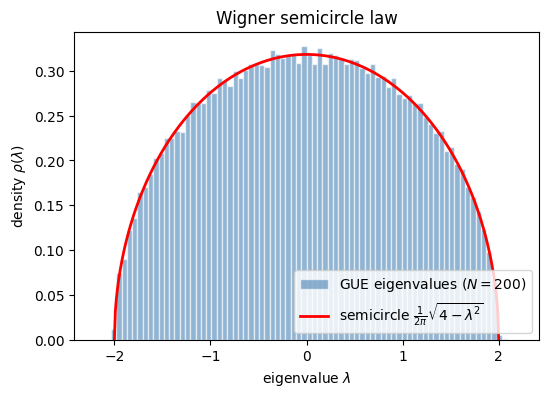

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

# GUE eigenvalues with the normalization that places the spectrum on [-2, 2].
rng = np.random.default_rng(0)
N_fig, n_mat = 200, 100
fig_evals = []
for _ in range(n_mat):
    G = rng.standard_normal((N_fig, N_fig)) + 1j*rng.standard_normal((N_fig, N_fig))
    H = (G + G.conj().T) / (2*np.sqrt(N_fig))
    fig_evals.extend(np.linalg.eigvalsh(H))
fig_evals = np.array(fig_evals)

lam_grid = np.linspace(-2, 2, 400)
rho_grid = np.sqrt(4 - lam_grid**2) / (2*np.pi)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(fig_evals, bins=80, range=(-2.2, 2.2), density=True, alpha=0.6,
        color='steelblue', edgecolor='white', label=f'GUE eigenvalues ($N={N_fig}$)')
ax.plot(lam_grid, rho_grid, 'r-', lw=2,
        label=r'semicircle $\frac{1}{2\pi}\sqrt{4-\lambda^2}$')
ax.set_xlabel(r'eigenvalue $\lambda$')
ax.set_ylabel(r'density $\rho(\lambda)$')
ax.set_title('Wigner semicircle law')
ax.legend()
plt.show()

## Takeaway

The even moments of the semicircle are the Catalan numbers, with $m_2 = 1$ and $m_4 = 2$. A histogram of GUE eigenvalues fills out the semicircle on $[-2, 2]$, matching the analytic density.

## Connections

The even moments of the semicircle are Catalan numbers, and they count the non-crossing pairings of the matrix indices. That same counting is what makes the [Weingarten calculus](../ch3/solution_ch3_tensor_weingarten_calculus.ipynb) tractable, where Haar averages reduce to sums over permutations and the leading contributions are again the non-crossing ones. The fluctuations around this average density are what produce the [level repulsion](solution_ch2_goe_spacing.ipynb) measured by the spacing distribution.

## References

- Marchenko and Pastur, *Distribution of eigenvalues for some sets of random matrices*, Mathematics of the USSR-Sbornik (1967). [doi](https://doi.org/10.1070/SM1967v001n04ABEH001994)
- Mehta, *Random matrices*, Academic Press (2004).
- Anderson et al., *An Introduction to Random Matrices*, Cambridge University Press (2010).
- Płodzień, *Information Scrambling, Quantum Chaos, and Haar-Random States*, lecture notes (2025). [arXiv:2511.14397](https://arxiv.org/abs/2511.14397)